In [1]:
# Install nessesary packages
%pip install pandas numpy scikit-learn matplotlib seaborn xgboost imbalanced-learn huggingface_hub dotenv mlflow scipy joblib

Note: you may need to restart the kernel to use updated packages.


In [37]:
import os
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from huggingface_hub import login, HfApi, create_repo, hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError

from dotenv import load_dotenv

import subprocess
import mlflow

from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.metrics import (
    classification_report,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler

# To be used for tuning the model
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

import joblib

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

True

#### Create a master folder and data sub folder

In [3]:
os.makedirs("predictive_maintenance", exist_ok=True)
os.makedirs("predictive_maintenance/data", exist_ok=True)

#### Register data in Hugging Face

In [4]:
# Declare repo id
repo_id = "subhradasgupta/predictive_maintenance"
repo_type = "dataset"

# Initialize API client
api = HfApi(token=os.getenv("HF_TOKEN"))

try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Space '{repo_id}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Space '{repo_id}' not found. Creating new space...")
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Space '{repo_id}' created.")

api.upload_folder(
    folder_path="./predictive_maintenance/data",
    repo_id=repo_id,
    repo_type=repo_type,
)

Space 'subhradasgupta/predictive_maintenance' already exists. Using it.


No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/subhradasgupta/predictive_maintenance/commit/0774e26b5385790dca70ea193be5c5daca09f407', commit_message='Upload folder using huggingface_hub', commit_description='', oid='0774e26b5385790dca70ea193be5c5daca09f407', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/subhradasgupta/predictive_maintenance', endpoint='https://huggingface.co', repo_type='dataset', repo_id='subhradasgupta/predictive_maintenance'), pr_revision=None, pr_num=None)

#### Loading data

In [38]:
# Loading the dataset
df = pd.read_csv("./predictive_maintenance/data/engine_data.csv")

In [6]:
# Checking the number of rows and columns in the data
df.shape

(19535, 7)

#### Data overview

In [7]:
# Make a copy of the original dataframe
data = df.copy()

In [8]:
# Preview first 5 rows
data.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.494,11.791,3.179,84.144,81.632,1
1,876,2.942,16.194,2.465,77.641,82.446,0
2,520,2.962,6.553,1.064,77.752,79.646,1
3,473,3.708,19.510,3.727,74.130,71.775,1
4,619,5.673,15.739,2.052,78.397,87.000,0


In [9]:
# Preview last 5 rows
data.tail()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
19530,902,4.117,4.981,4.347,75.952,87.925,1
19531,694,4.818,10.867,6.187,75.281,74.928,1
19532,684,2.673,4.927,1.904,76.845,86.337,1
19533,696,3.094,8.292,1.222,77.180,73.624,1
19534,504,3.775,3.962,2.039,75.564,80.421,1


In [10]:
# Check data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.isnull().sum()

Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

In [13]:
data.nunique()

Engine rpm           1379
Lub oil pressure    19534
Fuel pressure       19531
Coolant pressure    19534
lub oil temp        19530
Coolant temp        19532
Engine Condition        2
dtype: int64

In [14]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine rpm,19535.000,791.239,267.611,61.000,593.000,746.000,934.000,2239.000
Lub oil pressure,19535.000,3.304,1.022,0.003,2.519,3.162,4.055,7.266
Fuel pressure,19535.000,6.656,2.761,0.003,4.917,6.202,7.745,21.138
Coolant pressure,19535.000,2.335,1.036,0.002,1.600,2.167,2.849,7.479
lub oil temp,19535.000,77.643,3.111,71.322,75.726,76.817,78.072,89.581
Coolant temp,19535.000,78.427,6.207,61.673,73.895,78.347,82.915,195.528
Engine Condition,19535.000,0.631,0.483,0.000,0.000,1.000,1.000,1.000


In [15]:
# Check target classes
data["Engine Condition"].value_counts()

Engine Condition
1    12317
0     7218
Name: count, dtype: int64

In [16]:
# Extract column names
columns = data.columns[:].to_list()
columns

['Engine rpm',
 'Lub oil pressure',
 'Fuel pressure',
 'Coolant pressure',
 'lub oil temp',
 'Coolant temp',
 'Engine Condition']

### EDA - Univariate analysis

#### Check histogram for numeric columns

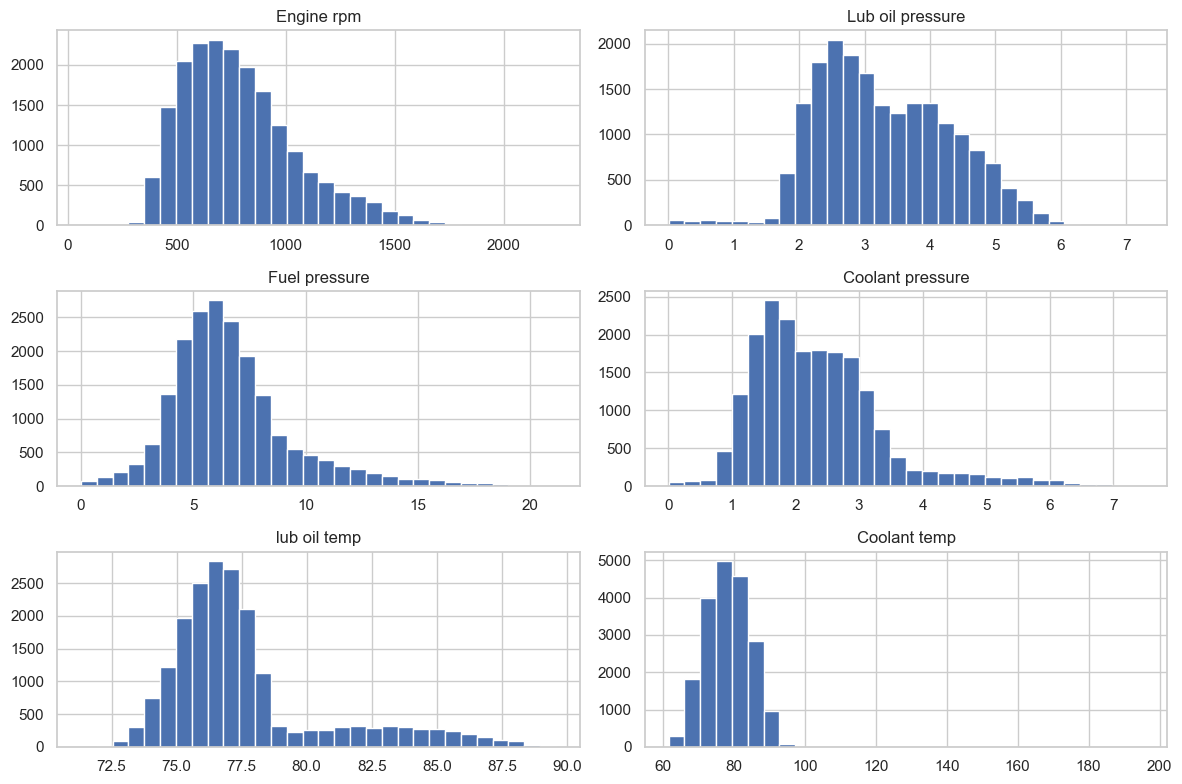

In [17]:
# Set style
sns.set(style="whitegrid")

# Histogram for numeric features
df[columns[:-1]].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

#### Check target variable using count plot

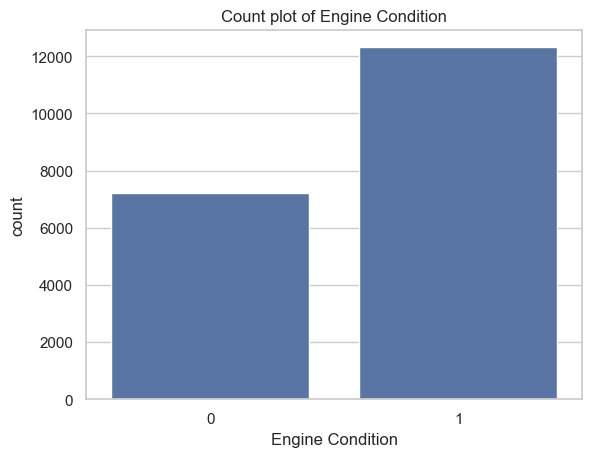

In [18]:
sns.countplot(data=df, x="Engine Condition")
plt.title(f"Count plot of Engine Condition")
plt.show()

### EDA - Bivariate analysis

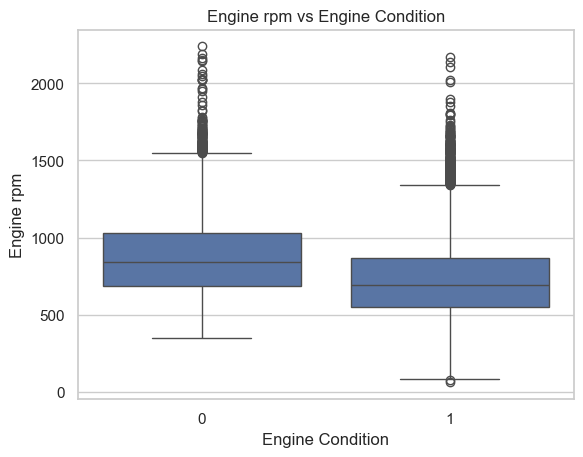

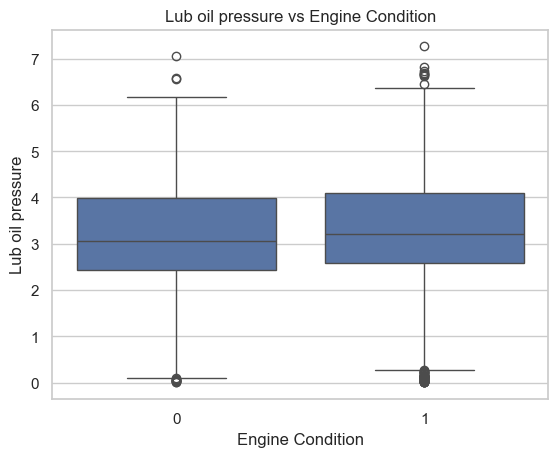

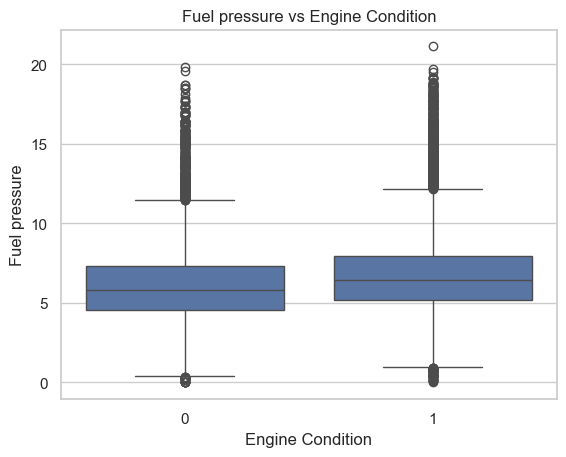

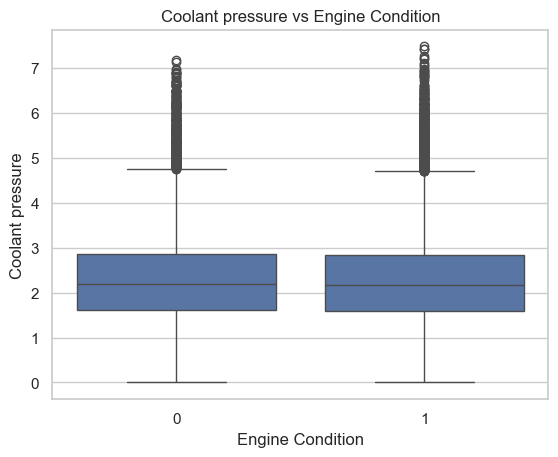

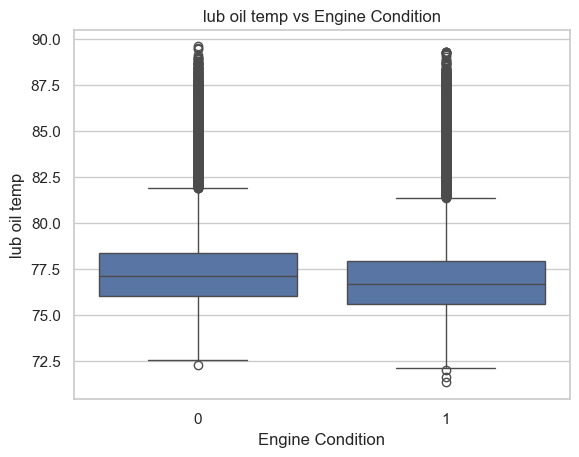

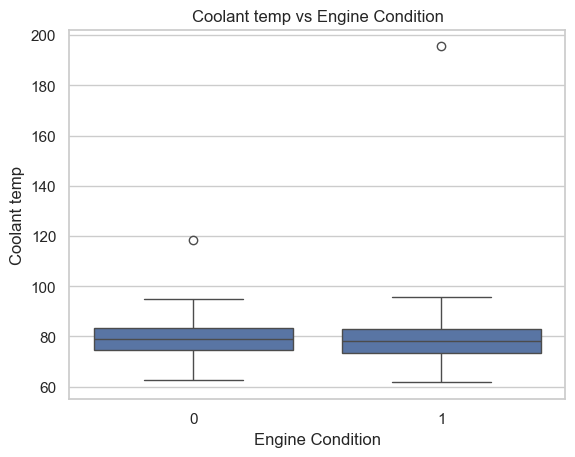

In [19]:
# Boxplots for numeric vs. target
for col in columns[:-1]:
    sns.boxplot(x="Engine Condition", y=col, data=df)
    plt.title(f"{col} vs Engine Condition")
    plt.show()

### EDA - Multivariate analysis

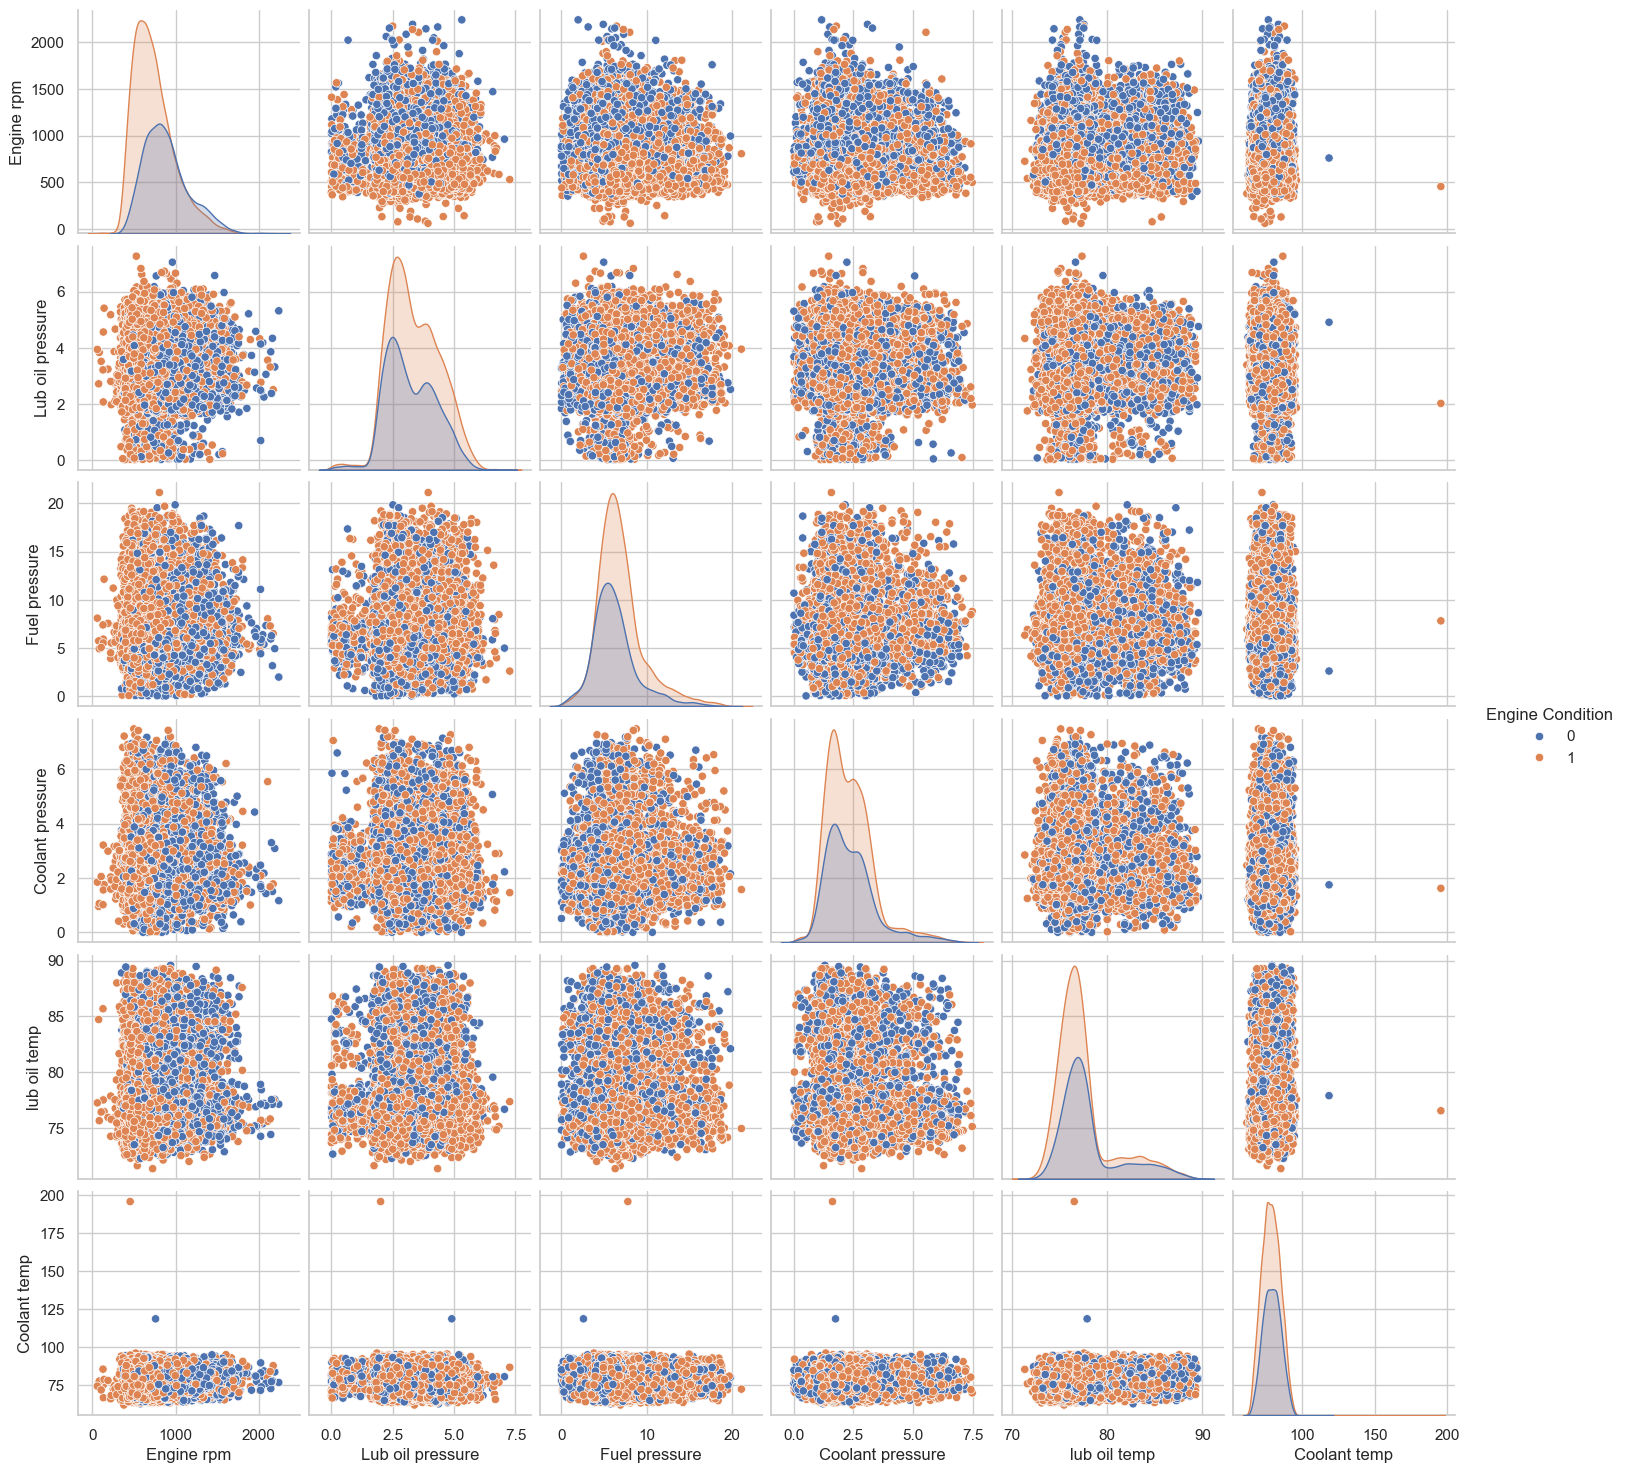

In [20]:
# Generate pairplot
sns.pairplot(data, hue="Engine Condition")

In [21]:
# Check for feature correlations
corr = data.corr(numeric_only=True)

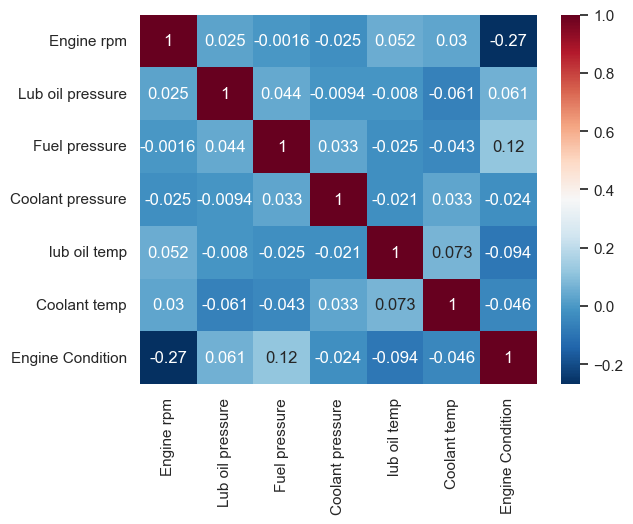

In [22]:
sns.heatmap(corr, annot=True, cmap="RdBu_r")
plt.show()

### EDA Insights

#### Feature Distribution Analysis
- Lubricating Oil Temperature (Lub oil temp) shows a long right-skewed distribution, indicating most observations occur at lower temperatures while a few extend toward higher values.
- Engine RPM is right skewed, suggesting that most engine operations occur at relatively lower RPM values with fewer observations at very high RPM.
- Lubricating Oil Pressure also exhibits a right-skewed distribution, indicating occasional high-pressure readings.
- Coolant Pressure shows a right-skewed distribution with a long tail, suggesting the presence of some unusually high values.
- Coolant Temperature appears approximately normally distributed, indicating a balanced spread of values around the mean.

#### Target Variable Distribution – Engine Condition
- The dataset is imbalanced, with more records representing engine failure than active/healthy engine states.

#### Relationship Between Features and Engine Condition

**Engine RPM vs Engine Condition**
- Engines operating at higher RPM values appear to be associated more frequently with better engine conditions.
- Both engine condition classes show a large number of outliers.

**Lubricating Oil Pressure vs Engine Condition**
- Higher oil pressure values show a slight tendency toward failed engine conditions.
- A significant number of outliers are present.

**Fuel Pressure vs Engine Condition**
- Lower fuel pressure appears to be associated with better engine condition.
- The distribution contains many outliers due to skewness.

**Coolant Pressure vs Engine Condition**
- No clear relationship is observed between coolant pressure and engine condition.
- The feature also contains numerous outliers.

**Lubricating Oil Temperature vs Engine Condition**
- Higher lubricating oil temperatures appear to be associated with better engine condition.
- A large number of outliers are present due to the skewed distribution.

**Coolant Temperature vs Engine Condition**
- No significant relationship is observed between coolant temperature and engine condition.
- Very few outliers are present compared to other features.

**Correlation Analysis**
- Engine RPM shows a negative correlation with Engine Condition, suggesting that higher RPM values tend to be associated with healthier engine states.
- Coolant Temperature has a negative correlation with Lubricating Oil Pressure and Fuel Pressure.
- Lubricating Oil Temperature also shows a negative correlation with Engine Condition.

### Data Preparation

In [23]:
# Load data set from Hugging face repo
DATASET_PATH = "hf://datasets/subhradasgupta/predictive_maintenance/engine_data.csv"
df = pd.read_csv(DATASET_PATH)
df.shape

(19535, 7)

In [24]:
# Separate features and target
X = df.drop(["Engine Condition"], axis=1)
y = df["Engine Condition"]

In [25]:
# Splitting data into training and test sets:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# Perform standardization
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(X_train_df.shape, X_test_df.shape, y_train.shape, y_test.shape)

# Save splitted data locally
X_train_df.to_csv("./predictive_maintenance/data/Xtrain.csv", index=False)
X_test_df.to_csv("./predictive_maintenance/data/Xtest.csv", index=False)
y_train.to_csv("./predictive_maintenance/data/ytrain.csv", index=False)
y_test.to_csv("./predictive_maintenance/data/ytest.csv", index=False)

(15628, 6) (3907, 6) (15628,) (3907,)


In [26]:
# Upload to Hugging face
api.upload_folder(
    folder_path="./predictive_maintenance/data",
    repo_id=repo_id,
    repo_type=repo_type,
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/subhradasgupta/predictive_maintenance/commit/0774e26b5385790dca70ea193be5c5daca09f407', commit_message='Upload folder using huggingface_hub', commit_description='', oid='0774e26b5385790dca70ea193be5c5daca09f407', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/subhradasgupta/predictive_maintenance', endpoint='https://huggingface.co', repo_type='dataset', repo_id='subhradasgupta/predictive_maintenance'), pr_revision=None, pr_num=None)

### Model Building with Experimentation Tracking

In [27]:
# Load the train and test data from the Hugging Face data space


# Reliable way to download items from huggingface.
def read_csv(file):
    path = hf_hub_download(
        repo_id="subhradasgupta/predictive_maintenance",
        filename=file,
        repo_type="dataset",
    )

    df = pd.read_csv(path)
    return df


# Load the data sets
Xtrain = read_csv("Xtrain.csv")
Xtest = read_csv("Xtest.csv")
ytrain = read_csv("ytrain.csv")
ytest = read_csv("ytest.csv")

In [28]:
# Start MLflow UI on port 5000
process = subprocess.Popen(["mlflow", "ui", "--port", "5000"])

In [29]:
mlflow.set_experiment("predictive_maintenance")

<Experiment: artifact_location='/Users/subhro/Downloads/great-learning/capstone-interim/predictive_maintenance/mlruns/1', creation_time=1773342958105, experiment_id='1', last_update_time=1773342958105, lifecycle_stage='active', name='predictive_maintenance', tags={}, workspace='default'>

**Parameter Selection for Model Evaluation**

Since the objective of this model is to predict the engine condition based on operational features, the evaluation metric must align with the business objective of detecting engine failures reliably.

In this problem, misclassification costs are asymmetric:

- If a healthy engine is incorrectly classified as faulty, it may lead to unnecessary inspection or maintenance, which has a relatively lower operational impact.

- However, if a faulty engine is incorrectly classified as healthy, the failure may go undetected, potentially leading to serious mechanical damage, downtime, and significant business losses.

Therefore, the model should prioritize minimizing false negatives, i.e., cases where a faulty engine is predicted as healthy.

For this reason, **Recall is chosen as the primary evaluation metric**, because recall measures the model's ability to **correctly identify actual failure cases.**

A **higher recall ensures that most engine failures are correctly detected**, which aligns with the business requirement of **preventing undetected engine faults**.

In [30]:
# This function will train the model using RandomizedSearchCV and also evaluate model performance
def train_eval_model(model, param_grid):
    # Type of scoring used to compare parameter combinations
    scorer = metrics.make_scorer(metrics.recall_score)

    with mlflow.start_run():
        # Calling RandomizedSearchCV
        randomized_cv = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            n_iter=30,
            cv=5,
            random_state=1,
            n_jobs=-1,
            scoring=scorer,
        )

        # Fitting parameters in RandomizedSearchCV
        randomized_cv.fit(Xtrain, ytrain)

        results = randomized_cv.cv_results_
        for i in range(len(results["params"])):
            param_set = results["params"][i]
            mean_score = results["mean_test_score"][i]
            std_score = results["std_test_score"][i]

            # Log each combination as a separate MLflow run
            with mlflow.start_run(nested=True):
                mlflow.log_params(param_set)
                mlflow.log_metric("mean_test_score", mean_score)
                mlflow.log_metric("std_test_score", std_score)

        # Best model
        mlflow.log_params(randomized_cv.best_params_)
        best_model = randomized_cv.best_estimator_

        # Declare classification thresold
        classification_threshold = 0.45

        # Evalute the best model for test data
        y_pred_train_proba = best_model.predict_proba(Xtrain)[:, 1]
        y_pred_train = (y_pred_train_proba >= classification_threshold).astype(int)

        y_pred_test_proba = best_model.predict_proba(Xtest)[:, 1]
        y_pred_test = (y_pred_test_proba >= classification_threshold).astype(int)

        train_report = classification_report(ytrain, y_pred_train, output_dict=True)
        test_report = classification_report(ytest, y_pred_test, output_dict=True)

        cm_train = confusion_matrix(y_train, y_pred_train)
        cm_test = confusion_matrix(y_test, y_pred_test)

        model_metrics = {
            "train_accuracy": train_report["accuracy"],
            "train_precision": train_report["1"]["precision"],
            "train_recall": train_report["1"]["recall"],
            "train_f1-score": train_report["1"]["f1-score"],
            "test_accuracy": test_report["accuracy"],
            "test_precision": test_report["1"]["precision"],
            "test_recall": test_report["1"]["recall"],
            "test_f1-score": test_report["1"]["f1-score"],
        }

        print(model_metrics)

        mlflow.log_metrics(model_metrics)

        return {
            "best_model": best_model,
            "best_params": randomized_cv.best_params_,
            "metrics": model_metrics,
            "cm_train": cm_train,
            "cm_test": cm_test,
        }

In [31]:
def show_confusion_matrix(cm, title):
    plt.figure(figsize=(5,4))
    labels = np.array([
        [f"TN\n{cm[0][0]}", f"FP\n{cm[0][1]}"],
        [f"FN\n{cm[1][0]}", f"TP\n{cm[1][1]}"]
    ])
    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        xticklabels=["Pred Negative", "Pred Positive"],
        yticklabels=["Actual Negative", "Actual Positive"],
        cbar=False
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()
    

In [40]:
def print_model_perf(result):
    print("Best model: ", result["best_model"])
    print("Model params: ", result["best_params"])
    print("Model scores: ", result["metrics"])
    show_confusion_matrix(result["cm_train"], "Confusion matrix - train")
    show_confusion_matrix(result["cm_test"], "Confusion matrix - test")

In [33]:
model = XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1)
param_grid = {
    "n_estimators": randint(100, 1000),
    "learning_rate": [0.01, 0.1],
    "gamma": uniform(0, 0.5),
    "max_depth": randint(3, 10),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
}
# Train and evaluate model
xgb_result = train_eval_model(model, param_grid)

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.


[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
INFO:     Started parent process [90130]
2026/03/14 21:35:08 INFO mlflow.server.jobs.utils: Starting huey consumer for job function run_online_trace_scorer
2026/03/14 21:35:08 INFO mlflow.server.jobs.utils: Starting huey consumer for job function optimize_prompts
2026/03/14 21:35:08 INFO mlflow.server.jobs.utils: Starting huey consumer for job function invoke_scorer
2026/03/14 21:35:08 INFO mlflow.server.jobs.utils: Starting huey consumer for job function run_online_session_scorer
2026/03/14 21:35:08 INFO mlflow.server.jobs.utils: Starting dedicated Huey consumer for periodic tasks
INFO:     Started server process [90133]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Started se

{'train_accuracy': 0.6432684924494497, 'train_precision': 0.6390098109284646, 'train_recall': 0.9980718489953319, 'train_f1-score': 0.7791641909288968, 'test_accuracy': 0.6347581264397236, 'test_precision': 0.6338501291989664, 'test_recall': 0.9959399106780349, 'test_f1-score': 0.7746723511763777}


Best model:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.6136685244743356), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=np.float64(0.31201499323867665), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=125,
              n_jobs=-1, num_parallel_tree=None, ...)
Model params:  {'colsample_bytree': np.float64(0.6136685244743356), 'gamma': np.float64(0.31201499323867665), 'learning_rate': 0.01, 'max_depth': 7, 'n_estimato

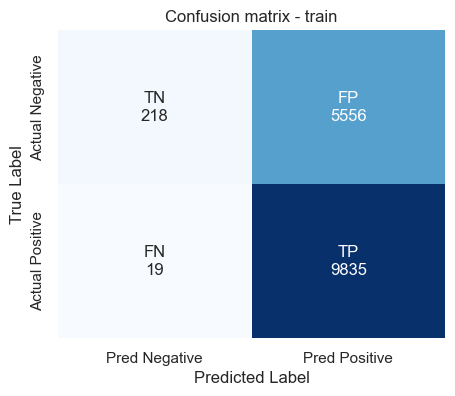

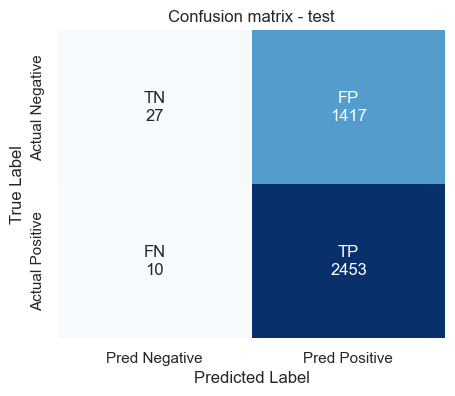

2026/03/15 01:49:38 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 13309b31-c10f-4ca6-9c83-95e9a60e5272.
[2026-03-15 01:49:38,480] INFO:huey.consumer.Scheduler:Scheduler:Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 13309b31-c10f-4ca6-9c83-95e9a60e5272.
2026/03/15 01:49:45 INFO huey: Executing mlflow.server.jobs.utils.online_scoring_scheduler: 13309b31-c10f-4ca6-9c83-95e9a60e5272
[2026-03-15 01:49:45,260] INFO:huey:Worker-5:Executing mlflow.server.jobs.utils.online_scoring_scheduler: 13309b31-c10f-4ca6-9c83-95e9a60e5272
2026/03/15 01:49:45 INFO huey: mlflow.server.jobs.utils.online_scoring_scheduler: 13309b31-c10f-4ca6-9c83-95e9a60e5272 executed in 0.006s
[2026-03-15 01:49:45,266] INFO:huey:Worker-5:mlflow.server.jobs.utils.online_scoring_scheduler: 13309b31-c10f-4ca6-9c83-95e9a60e5272 executed in 0.006s


In [ ]:
# Print XGBoostClassifier performance on training and test data
print_model_perf(xgb_result)

In [35]:
model = GradientBoostingClassifier(random_state=1)
param_grid = {
    "init": [
        AdaBoostClassifier(random_state=1),
        DecisionTreeClassifier(random_state=1),
    ],
    "n_estimators": np.arange(75, 150, 25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample": [0.5, 0.7, 1],
    "max_features": [0.5, 0.7, 1],
}
# Train and evaluate model
gbc_result = train_eval_model(model, param_grid)

{'train_accuracy': 0.6648323521883799, 'train_precision': 0.6653532024645364, 'train_recall': 0.9424599147554292, 'train_f1-score': 0.7800268772047707, 'test_accuracy': 0.6557460967494241, 'test_precision': 0.6590779738190097, 'test_recall': 0.9403166869671132, 'test_f1-score': 0.7749707210975406}


Best model:  GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=1,
                           n_estimators=np.int64(125), random_state=1,
                           subsample=0.5)
Model params:  {'subsample': 0.5, 'n_estimators': np.int64(125), 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)}
Model scores:  {'train_accuracy': 0.6648323521883799, 'train_precision': 0.6653532024645364, 'train_recall': 0.9424599147554292, 'train_f1-score': 0.7800268772047707, 'test_accuracy': 0.6557460967494241, 'test_precision': 0.6590779738190097, 'test_recall': 0.9403166869671132, 'test_f1-score': 0.7749707210975406}


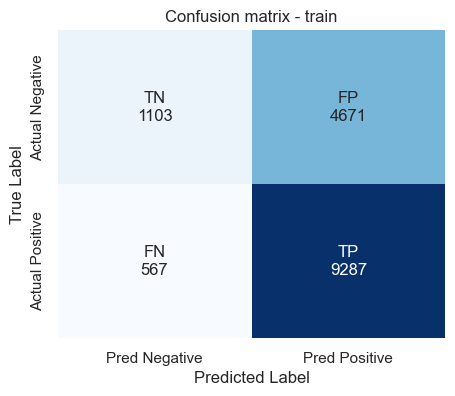

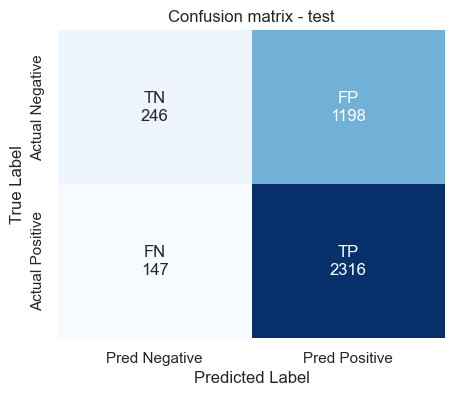

In [42]:
# Print GradientBoostingClassifier performance on training and test data
print_model_perf(gbc_result)

In [37]:
model = RandomForestClassifier(random_state=1)
param_grid = {
    "n_estimators": randint(100, 250),
    "max_depth": [8, 10, 15],
    "min_samples_split": randint(2, 7),
}
# Train and evaluate model
rfc_result = train_eval_model(model, param_grid)

2026/03/14 21:36:10 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 96d644e9-ca5c-4922-aacd-c98af44544c1.
[2026-03-14 21:36:10,400] INFO:huey.consumer.Scheduler:Scheduler:Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 96d644e9-ca5c-4922-aacd-c98af44544c1.
2026/03/14 21:36:17 INFO huey: Executing mlflow.server.jobs.utils.online_scoring_scheduler: 96d644e9-ca5c-4922-aacd-c98af44544c1
[2026-03-14 21:36:17,013] INFO:huey:Worker-1:Executing mlflow.server.jobs.utils.online_scoring_scheduler: 96d644e9-ca5c-4922-aacd-c98af44544c1
2026/03/14 21:36:17 INFO huey: mlflow.server.jobs.utils.online_scoring_scheduler: 96d644e9-ca5c-4922-aacd-c98af44544c1 executed in 0.005s
[2026-03-14 21:36:17,017] INFO:huey:Worker-1:mlflow.server.jobs.utils.online_scoring_scheduler: 96d644e9-ca5c-4922-aacd-c98af44544c1 executed in 0.005s


{'train_accuracy': 0.7061684156641925, 'train_precision': 0.6941984056687334, 'train_recall': 0.9544347473107367, 'train_f1-score': 0.803777454918383, 'test_accuracy': 0.654978244177118, 'test_precision': 0.6619227417949463, 'test_recall': 0.9252943564758425, 'test_f1-score': 0.7717575347104639}


Best model:  RandomForestClassifier(max_depth=8, min_samples_split=6, n_estimators=102,
                       random_state=1)
Model params:  {'max_depth': 8, 'min_samples_split': 6, 'n_estimators': 102}
Model scores:  {'train_accuracy': 0.7061684156641925, 'train_precision': 0.6941984056687334, 'train_recall': 0.9544347473107367, 'train_f1-score': 0.803777454918383, 'test_accuracy': 0.654978244177118, 'test_precision': 0.6619227417949463, 'test_recall': 0.9252943564758425, 'test_f1-score': 0.7717575347104639}


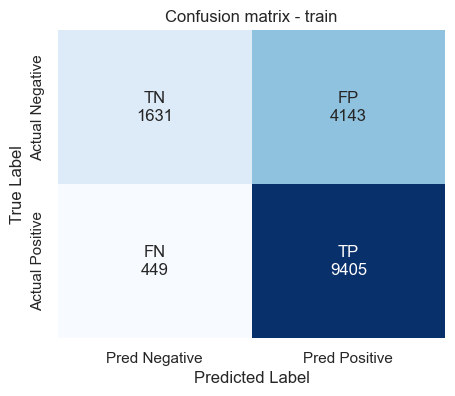

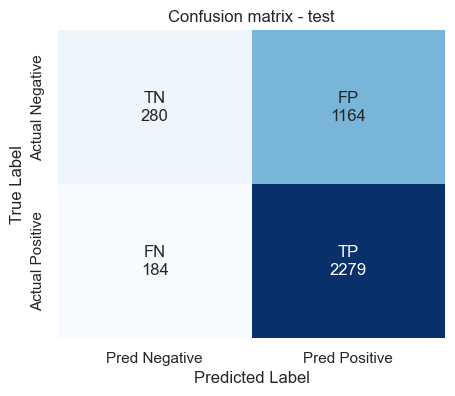

2026/03/15 01:50:38 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 44f9a082-e21d-401c-88e1-0a4a2efa8139.
[2026-03-15 01:50:38,482] INFO:huey.consumer.Scheduler:Scheduler:Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 44f9a082-e21d-401c-88e1-0a4a2efa8139.
2026/03/15 01:50:43 INFO huey: Executing mlflow.server.jobs.utils.online_scoring_scheduler: 44f9a082-e21d-401c-88e1-0a4a2efa8139
[2026-03-15 01:50:43,117] INFO:huey:Worker-5:Executing mlflow.server.jobs.utils.online_scoring_scheduler: 44f9a082-e21d-401c-88e1-0a4a2efa8139
2026/03/15 01:50:43 INFO huey: mlflow.server.jobs.utils.online_scoring_scheduler: 44f9a082-e21d-401c-88e1-0a4a2efa8139 executed in 0.005s
[2026-03-15 01:50:43,123] INFO:huey:Worker-5:mlflow.server.jobs.utils.online_scoring_scheduler: 44f9a082-e21d-401c-88e1-0a4a2efa8139 executed in 0.005s
2026/03/15 01:51:38 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.u

In [43]:
# Print RandomForrestClassifier performance on training and test data
print_model_perf(rfc_result)

### Save best model to HuggingFace

In [39]:
# As per the model performance we can observe that XGBoost performs best, so we will upload XGBoost to HuggingFace Hub
# Save the model locally
model_path = "xgb_model_v1.joblib"
joblib.dump(xgb_result["best_model"], model_path)

# Upload to Hugging Face
repo_id = "subhradasgupta/predictive_maintenance"
repo_type = "model"

# Step 1: Check if the space exists
try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Space '{repo_id}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Space '{repo_id}' not found. Creating new space...")
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Space '{repo_id}' created.")
# Step 2: Upload the model file to repo
api.upload_file(
    path_or_fileobj="xgb_model_v1.joblib",
    path_in_repo="xgb_model_v1.joblib",
    repo_id=repo_id,
    repo_type=repo_type,
)

Space 'subhradasgupta/predictive_maintenance' already exists. Using it.


Processing Files (1 / 1): 100%|██████████|  898kB /  898kB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/subhradasgupta/predictive_maintenance/commit/e6753fcf1647e3d7e7e4f7d683aacf4196b8418d', commit_message='Upload xgb_model_v1.joblib with huggingface_hub', commit_description='', oid='e6753fcf1647e3d7e7e4f7d683aacf4196b8418d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/subhradasgupta/predictive_maintenance', endpoint='https://huggingface.co', repo_type='model', repo_id='subhradasgupta/predictive_maintenance'), pr_revision=None, pr_num=None)

2026/03/14 21:37:10 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 714e6279-b0b6-425d-8b47-ae74665b3bc0.
[2026-03-14 21:37:10,399] INFO:huey.consumer.Scheduler:Scheduler:Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 714e6279-b0b6-425d-8b47-ae74665b3bc0.
2026/03/14 21:37:14 INFO huey: Executing mlflow.server.jobs.utils.online_scoring_scheduler: 714e6279-b0b6-425d-8b47-ae74665b3bc0
[2026-03-14 21:37:14,892] INFO:huey:Worker-1:Executing mlflow.server.jobs.utils.online_scoring_scheduler: 714e6279-b0b6-425d-8b47-ae74665b3bc0
2026/03/14 21:37:14 INFO huey: mlflow.server.jobs.utils.online_scoring_scheduler: 714e6279-b0b6-425d-8b47-ae74665b3bc0 executed in 0.006s
[2026-03-14 21:37:14,899] INFO:huey:Worker-1:mlflow.server.jobs.utils.online_scoring_scheduler: 714e6279-b0b6-425d-8b47-ae74665b3bc0 executed in 0.006s
2026/03/14 21:38:10 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.u

In [9]:
from dotenv import load_dotenv
load_dotenv()

True

### Model deployment

#### Prepare scripts to automate the entire workflow.
We should create script for each step of Machine Learning as mentioned in Rubrics
- Register dataset
- Data preparation
- Model trainig
- Deployment

In [30]:
import os

# Create a folder for storing the model building files
os.makedirs("predictive_maintenance/model_building", exist_ok=True)
os.makedirs("predictive_maintenance/deployment", exist_ok=True)
os.makedirs("predictive_maintenance/hosting", exist_ok=True)

**Dataset registration script**

In [47]:
%%writefile predictive_maintenance/model_building/data_register.py

from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError
from huggingface_hub import HfApi, create_repo
import os

# Declare repo id
repo_id = "subhradasgupta/predictive_maintenance"
repo_type = "dataset"

# Initialize API client
api = HfApi(token=os.getenv("HF_TOKEN"))

try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Space '{repo_id}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Space '{repo_id}' not found. Creating new space...")
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Space '{repo_id}' created.")
    
print("Uploading folder...")

api.upload_folder(
    folder_path="./predictive_maintenance/data",
    repo_id=repo_id,
    repo_type=repo_type,
)
print("Folder uploaded...")

Overwriting predictive_maintenance/model_building/data_register.py


In [19]:
%run ./predictive_maintenance/model_building/data_register.py

Space 'subhradasgupta/predictive_maintenance' already exists. Using it.
Uploading folder...


No files have been modified since last commit. Skipping to prevent empty commit.


Folder uploaded...


**Data preparation script**

In [48]:
%%writefile predictive_maintenance/model_building/prep.py

# for data manipulation
import pandas as pd
import sklearn

# for creating a folder
import os

# for data preprocessing and pipeline creation
from sklearn.model_selection import train_test_split

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# Define constants for the dataset and output paths
api = HfApi(token=os.getenv("HF_TOKEN"))

# Load data set from Hugging face repo
DATASET_PATH = "hf://datasets/subhradasgupta/predictive_maintenance/engine_data.csv"
df = pd.read_csv(DATASET_PATH)
print("Dataset loaded successfully.")

# Separate features and target
X = df.drop(["Engine Condition"], axis=1)
y = df["Engine Condition"]

# Splitting data into training and test sets:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print("Created training and test dataset.")

# Perform standardization
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Data preprossing done.")
print(X_train_df.shape, X_test_df.shape, y_train.shape, y_test.shape)

# Prepare input csv
input_df = X_test_df.tail(1)
input_df.to_csv("input.csv", index=False)

# Save splitted data locally
X_train_df.to_csv("Xtrain.csv", index=False)
X_test_df.to_csv("Xtest.csv", index=False)
y_train.to_csv("ytrain.csv", index=False)
y_test.to_csv("ytest.csv", index=False)

print("Dataset saved locally.")

files = ["input.csv", "Xtrain.csv", "Xtest.csv", "ytrain.csv", "ytest.csv"]

# Upload the splitted data to Hugging Face
for file_path in files:
    print(f"Uploading file: {file_path} to HuggingFace")
    api.upload_file(
        path_or_fileobj=file_path,
        path_in_repo=file_path.split("/")[-1],  # just the filename
        repo_id="subhradasgupta/predictive_maintenance",
        repo_type="dataset",
    )
    print(f"Uploaded file to HuggingFace successfully")

Overwriting predictive_maintenance/model_building/prep.py


In [49]:
%run ./predictive_maintenance/model_building/prep.py

Dataset loaded successfully.
Created training and test dataset.
Data preprossing done.
(15628, 6) (3907, 6) (15628,) (3907,)
Dataset saved locally.
Uploading file: input.csv to HuggingFace
Uploaded file to HuggingFace successfully
Uploading file: Xtrain.csv to HuggingFace


No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded file to HuggingFace successfully
Uploading file: Xtest.csv to HuggingFace


No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded file to HuggingFace successfully
Uploading file: ytrain.csv to HuggingFace


No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded file to HuggingFace successfully
Uploading file: ytest.csv to HuggingFace


No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded file to HuggingFace successfully


**Model training script**

In [28]:
%%writefile predictive_maintenance/model_building/train.py

# Libraries to help with reading and manipulating data

from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.metrics import (
    classification_report,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

import joblib
import os
# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi, create_repo
from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError

from huggingface_hub import hf_hub_download

# Reliable way to download items from huggingface.
def read_csv(file):
    print(f"Loading {file} from HuggingFace..")
    path = hf_hub_download(
        repo_id="subhradasgupta/predictive_maintenance",
        filename=file,
        repo_type="dataset",
    )

    df = pd.read_csv(path)
    print(f"{file} loaded.")
    return df


# Load the data sets
Xtrain = read_csv("Xtrain.csv")
Xtest = read_csv("Xtest.csv")
ytrain = read_csv("ytrain.csv")
ytest = read_csv("ytest.csv")

# This code will train the model using RandomizedSearchCV and also evaluate model performance
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

model = XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1)
param_grid = {
    "n_estimators": randint(100, 1000),
    "learning_rate": [0.01, 0.1],
    "gamma": uniform(0, 0.5),
    "max_depth": randint(3, 10),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
}

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    random_state=1,
    n_jobs=-1,
    scoring=scorer,
)

print("Running RandomizedSearchCV ..")
# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(Xtrain, ytrain)

results = randomized_cv.cv_results_

print("Best model selected.")

# Best model
best_model = randomized_cv.best_estimator_

print("Saving best model locally..")
# Save the model locally
model_path = "xgb_model_v1.joblib"
joblib.dump(best_model, model_path)
print("Model dump success.")

# Upload to Hugging Face
repo_id = "subhradasgupta/predictive_maintenance"
repo_type = "model"

# Initialize API client
api = HfApi(token=os.getenv("HF_TOKEN"))

print("Uploading model to HuggingFace..")
# Step 1: Check if the space exists
try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Space '{repo_id}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Space '{repo_id}' not found. Creating new space...")
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Space '{repo_id}' created.")
# Step 2: Upload the model file to repo
api.upload_file(
    path_or_fileobj="xgb_model_v1.joblib",
    path_in_repo="xgb_model_v1.joblib",
    repo_id=repo_id,
    repo_type=repo_type,
)
print("Model uploaded to HuggingFace.")

Overwriting predictive_maintenance/model_building/train.py


In [29]:
%run predictive_maintenance/model_building/train.py

Loading Xtrain.csv from HuggingFace..
Xtrain.csv loaded.
Loading Xtest.csv from HuggingFace..
Xtest.csv loaded.
Loading ytrain.csv from HuggingFace..
ytrain.csv loaded.
Loading ytest.csv from HuggingFace..
ytest.csv loaded.
Running RandomizedSearchCV ..
Best model selected.
Saving best model locally..
Model dump success.
Uploading model to HuggingFace..
Space 'subhradasgupta/predictive_maintenance' already exists. Using it.


Processing Files (1 / 1): 100%|██████████|  898kB /  898kB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Model uploaded to HuggingFace.


**Streamlit App**

In [52]:
%%writefile predictive_maintenance/deployment/app.py
import streamlit as st
import pandas as pd
from huggingface_hub import hf_hub_download
import joblib
import os

# Reliable way to download items from huggingface.
def read_csv(file):
    print(f"Loading {file} from HuggingFace..")
    path = hf_hub_download(
        repo_id="subhradasgupta/predictive_maintenance",
        filename=file,
        repo_type="dataset",
    )

    df = pd.read_csv(path)
    print(f"{file} loaded.")
    return df


# Load the data sets
input_df = read_csv("input.csv")
first_row = input_df.iloc[0]
input_dict = first_row.to_dict()

# Download and load the model
model_path = hf_hub_download(
    repo_id="subhradasgupta/predictive_maintenance", filename="xgb_model_v1.joblib"
)
model = joblib.load(model_path)

# Streamlit UI for Engine Failure Prediction
st.title("Predictive Maintenance - Engine Failure Prediction app")
st.write(
    """Predict potential engine failure.
Please enter engine properties below to get a prediction.
"""
)

# User inputs
engine_rpm = st.number_input(
    "Engine rpm",
    value=input_dict.get("Engine rpm"),
)
lub_oil_pressure = st.number_input(
    "Lub oil pressure",
    value=input_dict.get("Lub oil pressure"),
)
fuel_pressure = st.number_input(
    "Fuel pressure",
    value=input_dict.get("Fuel pressure"),
)
coolant_pressure = st.number_input(
    "Coolant pressure",
    value=input_dict.get("Coolant pressure"),
)
lub_oil_temp = st.number_input(
    "lub oil temp",
    value=input_dict.get("lub oil temp"),
)
coolant_temp = st.number_input(
    "Coolant temp",
    value=input_dict.get("Engine rpm"),
)


# Assemble input into DataFrame
input_data = pd.DataFrame(
    [
        {
            "Engine rpm": engine_rpm,
            "Lub oil pressure": lub_oil_pressure,
            "Fuel pressure": fuel_pressure,
            "Coolant pressure": coolant_pressure,
            "lub oil temp": lub_oil_temp,
            "Coolant temp": coolant_temp,
        }
    ]
)


if st.button("Predict"):
    prediction = model.predict(input_data)[0]
    result = "Engine is Faulty" if prediction > 0.5 else "Engine is OK"
    st.subheader("Prediction Result:")
    st.success(f"The model predicts: **{result}**")

Overwriting predictive_maintenance/deployment/app.py


#### Docker file

In [53]:
%%writefile predictive_maintenance/deployment/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.14

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user \
	PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app

COPY --chown=user . $HOME/app

# Define the command to run the Streamlit app on port "8501" and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing predictive_maintenance/deployment/Dockerfile


**Create input csv**

In [42]:
input_df = X_test_df.tail(1)
input_df

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
19534,504,3.775,3.962,2.039,75.564,80.421,1


In [ ]:
# Save the input dataframe
input_df.to_csv("./predictive_maintenance/data/input.csv")

#### Dependency management using requirements.txt
Create a file with all the dependency named requirements.txt

In [54]:
%%writefile predictive_maintenance/deployment/requirements.txt
pandas==2.3.3
huggingface_hub==1.6.0
streamlit==1.55.0
joblib==1.5.3
scikit-learn==1.8.0
xgboost==3.2.0
numpy==2.4.3
imbalanced-learn==0.14.1
scipy==1.17.1
joblib==1.5.3



Writing predictive_maintenance/deployment/requirements.txt


#### Hosting script

In [ ]:
%%writefile predictive_maintenance/hosting/hosting.py
from huggingface_hub import HfApi
import os

# Hosting script that can push all the deployment files into the Hugging Face space
api = HfApi(token=os.getenv("HF_TOKEN"))
api.upload_folder(
    folder_path="./predictive_maintenance/deployment",  # the local folder containing your files
    repo_id="subhradasgupta/predictive_maintenance",    # the target repo
    repo_type="space",                                  # dataset, model, or space
    path_in_repo="",                                    # optional: subfolder path inside the repo
)

Overwriting predictive_maintenance/hosting/hosting.py


### Automated GitHub Actions Workflow

In [ ]:
%%writefile .github/workflows/pipeline.yml

name: Predictive Maintenance Pipeline

on:
  push:
    branches:
      - main  # Automatically triggers on push to the main branch

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r predictive_maintenance/deployment/requirements.txt
      - name: Upload Dataset to Hugging Face Hub
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python predictive_maintenance/model_building/data_register.py

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r predictive_maintenance/deployment/requirements.txt
      - name: Run Data Preparation
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python predictive_maintenance/model_building/prep.py

  model-traning:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r predictive_maintenance/deployment/requirements.txt
      - name: Model Building
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python predictive_maintenance/model_building/train.py

  deploy-hosting:
    runs-on: ubuntu-latest
    needs: [model-traning,data-prep,register-dataset]
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: pip install -r predictive_maintenance/deployment/requirements.txt
      - name: Push files to Frontend Hugging Face Space
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python predictive_maintenance/hosting/hosting.py

Overwriting .github/workflows/pipeline.yml


### Setup git repository

In [ ]:
# Set your Git identity (replace with your details)
!git config --global user.email "subhradasgupta47@gmail.com"

!git init

!echo "# Predictive Maintenance" >> README.md
!git add .
!git commit -m "initial commit"
!git branch -M main
!git remote add origin https://github.com/subhra47/predictive_maintenance.git
!git push -u origin main

**Dataset in HuggingFace**

https://huggingface.co/datasets/subhradasgupta/predictive_maintenance/tree/main

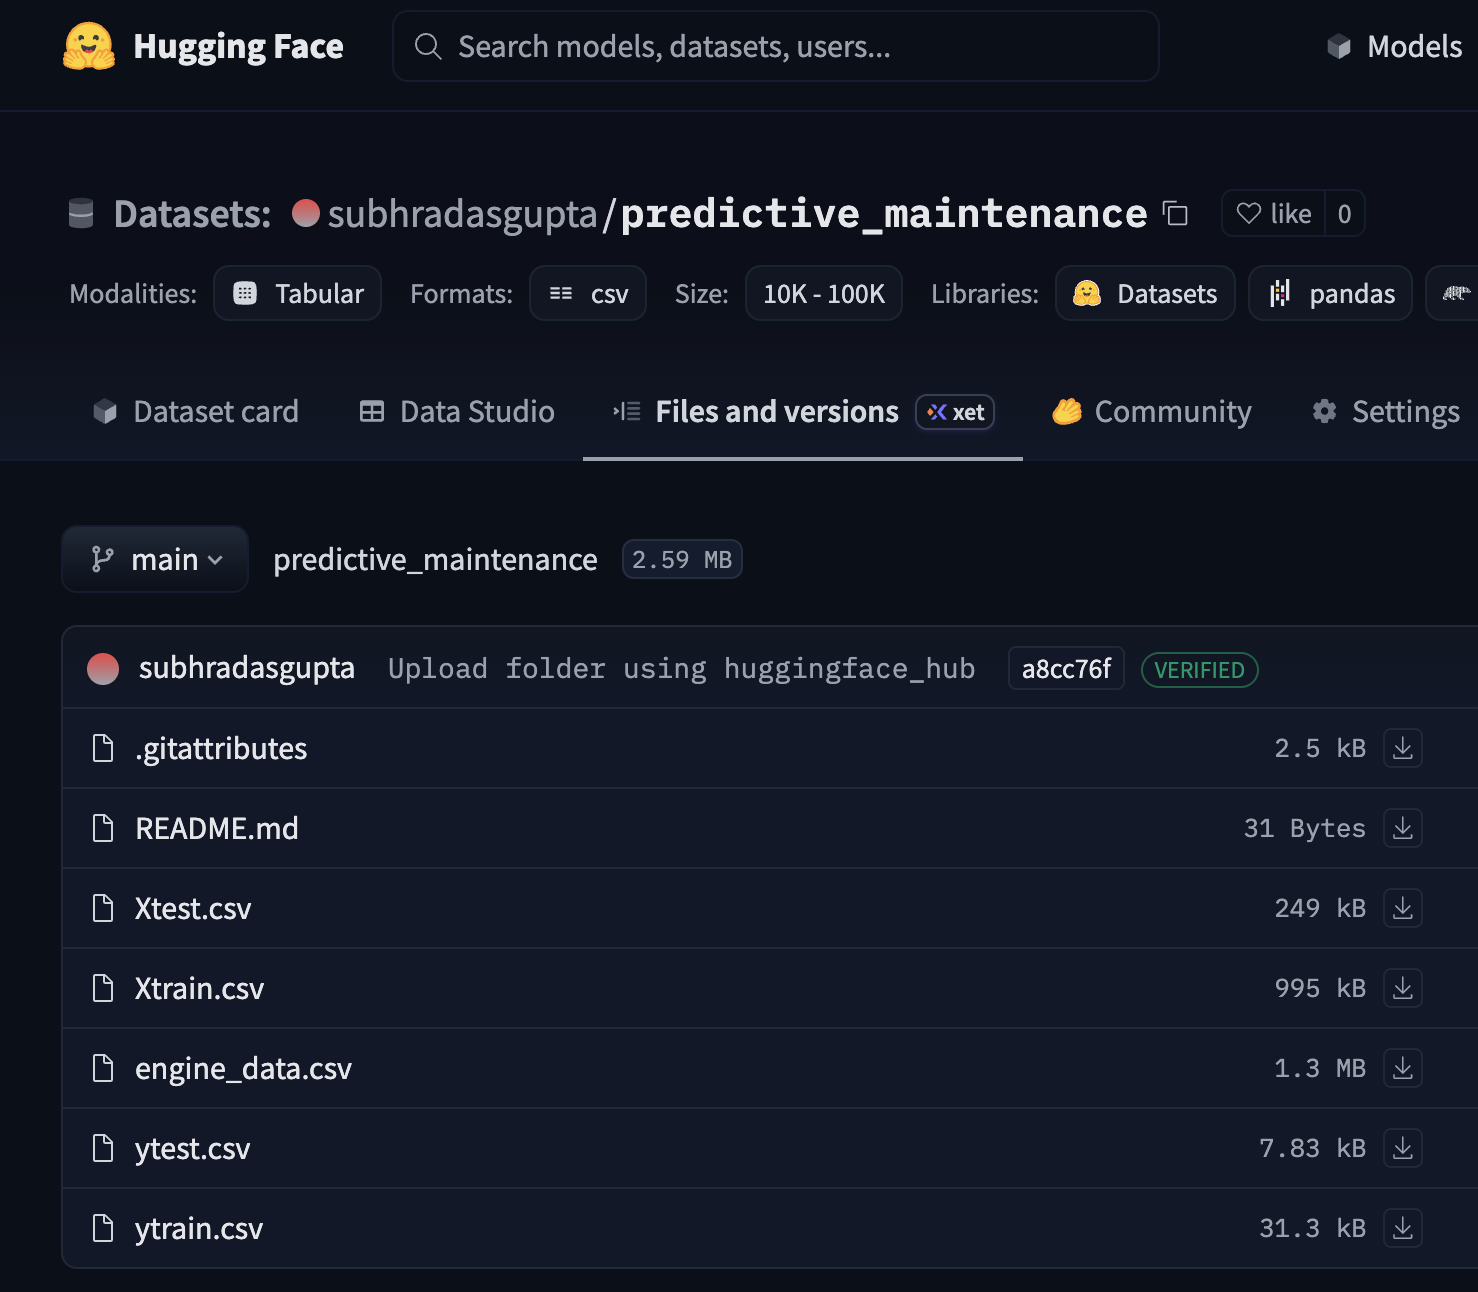

**Model uploaded to HuggingFace**

https://huggingface.co/subhradasgupta/predictive_maintenance/tree/main

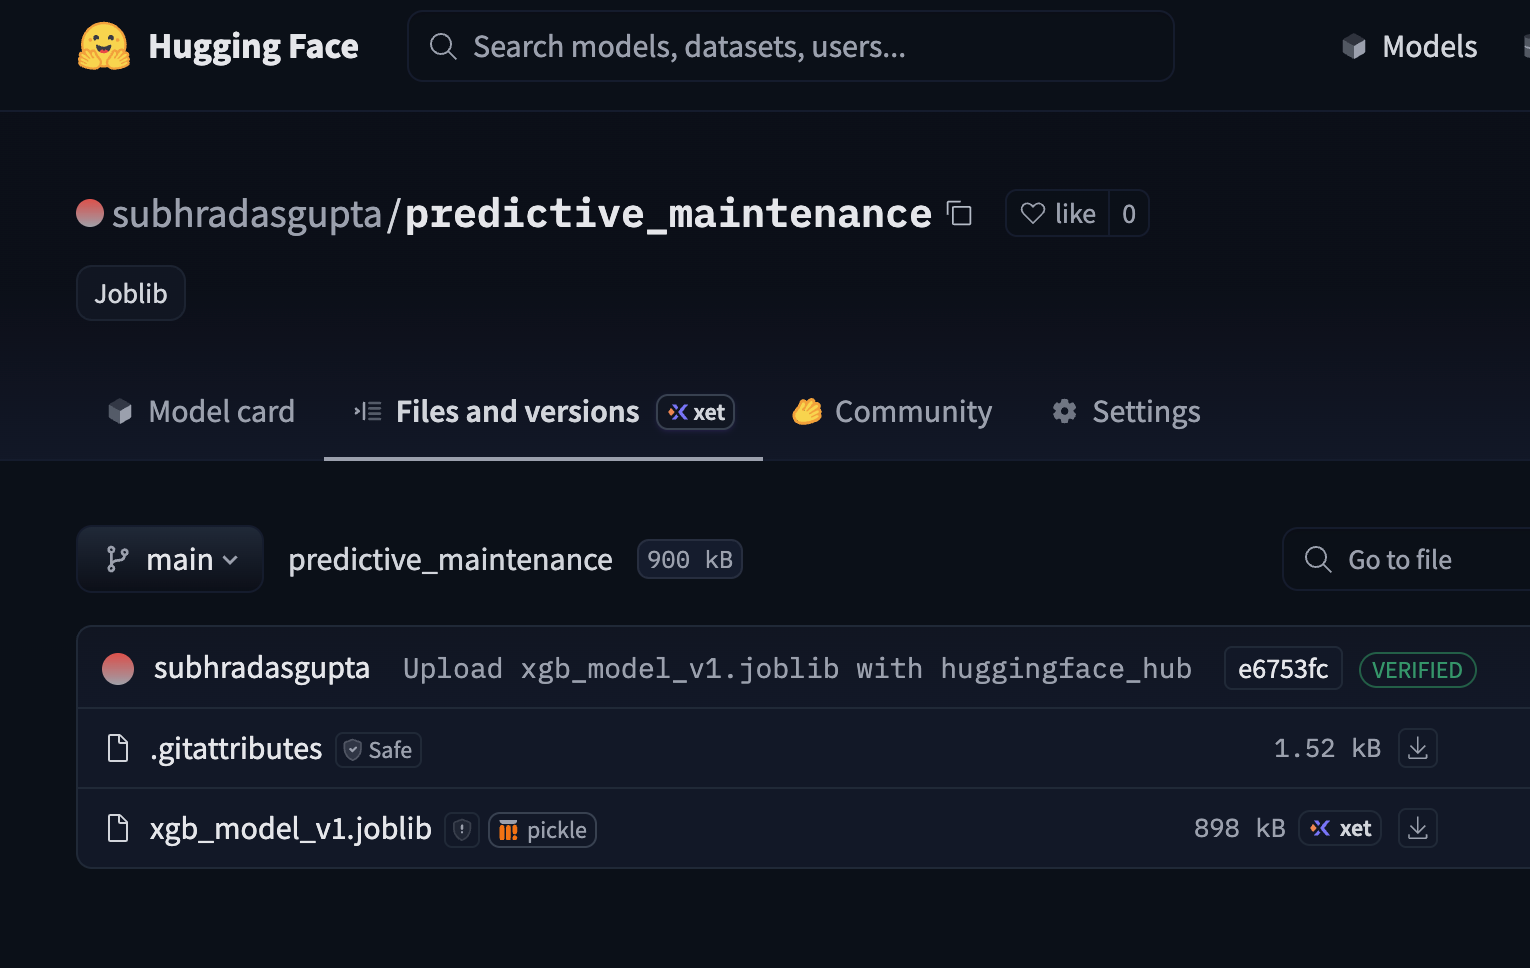